# Chlorine Injection Example

In [33]:
import numpy
from epyt_flow.data.benchmarks import load_leakdb_scenarios
from epyt_flow.simulation import ScenarioSimulator, EpanetConstants
from epyt_flow.utils import to_seconds
from epyt_flow.simulation import ScenarioSimulator, EpanetConstants, ScenarioConfig

We have to use the net1 network

In [38]:
config, = load_leakdb_scenarios(scenarios_id=[1], use_net1=True, verbose=False)
network_config = ScenarioConfig(scenario_config=config,
                            f_msx_in="../arsenic_contamination.msx")

In [39]:
sim = ScenarioSimulator(scenario_config=network_config)

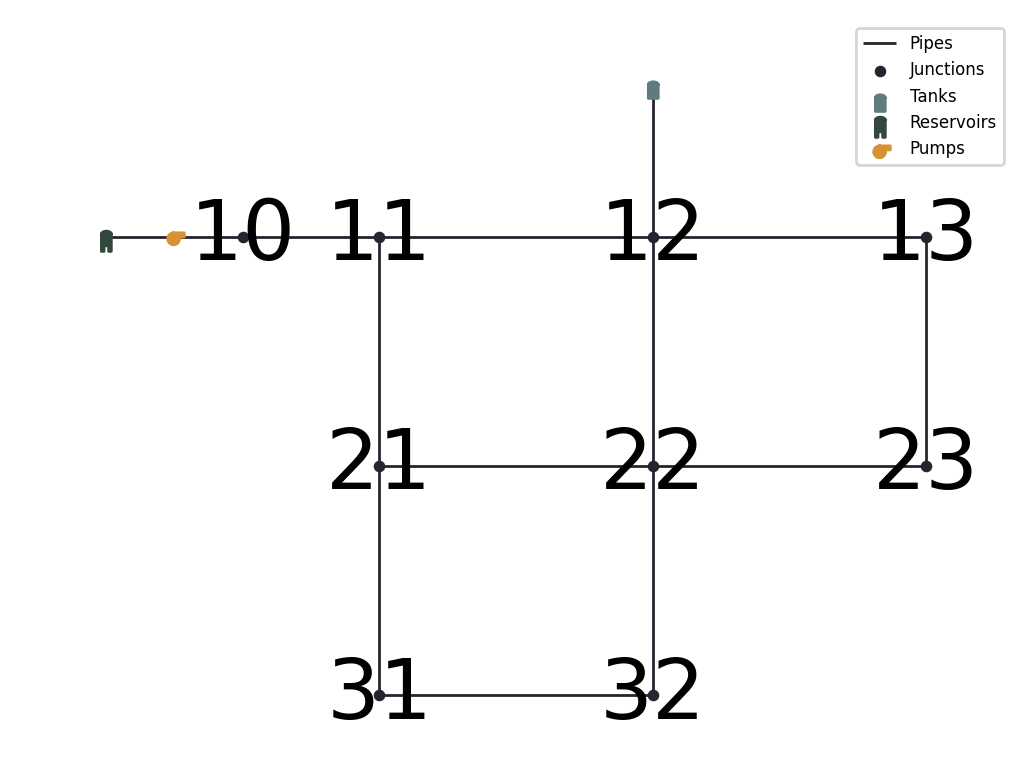

In [40]:
from epyt_flow.simulation import ScenarioSimulator
from epyt_flow.visualization import ScenarioVisualizer
vis = ScenarioVisualizer(sim)
vis.add_labels(font_size=30)   # labels nodes by default
vis.show_plot()

Set simulation duration to 12 hours:

In [44]:
# Set simulation duration to 21 days
sim.set_general_parameters(simulation_duration=to_seconds(days=21))

# Place some chlorine sensors and also keep track of the contaminant
cl_sensor_locations = ["10", "11", "12", "13", "21", "22", "23", "31", "32"]
all_nodes = sim.sensor_config.nodes
sim.set_bulk_species_node_sensors({"Chlorine": cl_sensor_locations,
                                           # Also: Keep track of the contaminant
                                           "AsIII": all_nodes})   # Arsenite

In [45]:
sim.enable_chemical_analysis()

Sets the concentration at node "1" (reservoir) to 1.0 for all time steps by calling [add_quality_source()](https://epyt-flow.readthedocs.io/en/stable/epyt_flow.simulation.html#epyt_flow.simulation.scenario_simulator.ScenarioSimulator.add_quality_source) -- this creates a new source of the chemical being analyzed:

In [46]:
sim.add_quality_source(node_id="10",
                       pattern=numpy.array([1.]),
                       source_type=EpanetConstants.EN_CONCEN)

/Users/esther/dev/Arsenic-Detection/.venv/lib/python3.12/site-packages/epanet_plus/epanet_wrapper.py:139: RuntimeWarning: Error 215: function call contains duplicate ID label
  warnings.warn(self._last_error_desc, RuntimeWarning)


Places quality sensors at all nodes -- i.e. measuring the chemical concentration at all nodes:

In [47]:
sim.set_node_quality_sensors(sensor_locations=sim.sensor_config.nodes)

Run the entire simulation:

In [48]:
scada_data = sim.run_simulation()

Retrieve and how the simulated chemical concentrations at the first 5 nodes -- note the transport delay!

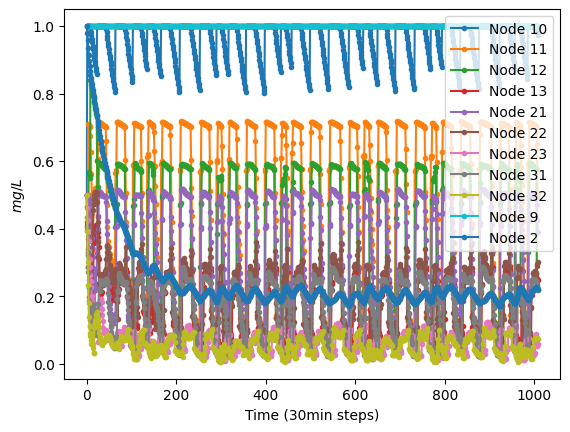

<Axes: xlabel='Time (30min steps)', ylabel='$mg/L$'>

In [49]:
scada_data.plot_nodes_quality()

Do not forget to close the simulation!

In [50]:
# Close simulator
sim.close()